## Exercise 2.0 - Iris flower dataset (*)

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

### a, Check keys on iris loaded data to explore

In [9]:
iris = load_iris(as_frame=True)

In [10]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [11]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [25]:
iris.data.shape

(150, 4)

In [26]:
iris.target.shape

(150,)

In [12]:
iris.target.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [13]:
iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [24]:
import textwrap
print(textwrap.fill(iris.DESCR, width=90))

.. _iris_dataset:  Iris plants dataset --------------------  **Data Set Characteristics:**
:Number of Instances: 150 (50 in each of three classes) :Number of Attributes: 4 numeric,
predictive attributes and the class :Attribute Information:     - sepal length in cm     -
sepal width in cm     - petal length in cm     - petal width in cm     - class:
- Iris-Setosa             - Iris-Versicolour             - Iris-Virginica  :Summary
Statistics:  ============== ==== ==== ======= ===== ====================
Min  Max   Mean    SD   Class Correlation ============== ==== ==== ======= =====
==================== sepal length:   4.3  7.9   5.84   0.83    0.7826 sepal width:    2.0
4.4   3.05   0.43   -0.4194 petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!) ============== ==== ==== =======
===== ====================  :Missing Attribute Values: None :Class Distribution: 33.3% for
each of 3 classes. :Creator: R.A. Fisher :Donor: Mic

In [21]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [22]:
iris.filename

'iris.csv'

In [23]:
iris.data_module

'sklearn.datasets.data'

### b, After initial exploration of dataset, insert into DF
### c, Do EDA
### d, Make correlation heat map. Explore numbers

In [30]:
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [45]:
# rename the numerical targets in legend
species_names = {0:"Setosa", 1:"Versicolor", 2:"Virginica"}
df["Species"] = df["target"].map(species_names)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

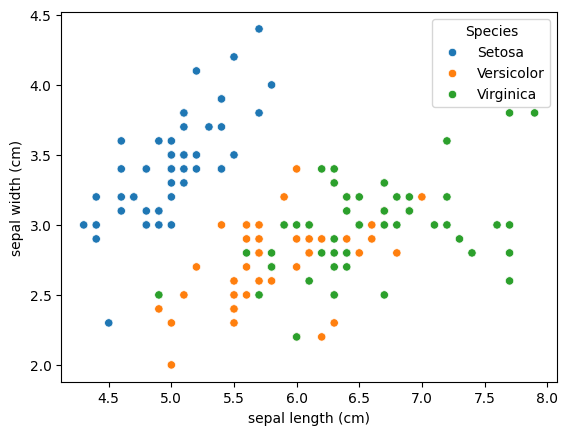

In [46]:
# heat map / scatter plot of how the features relate
sns.scatterplot(data=df, x= "sepal length (cm)", y= "sepal width (cm)", hue= "Species")

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

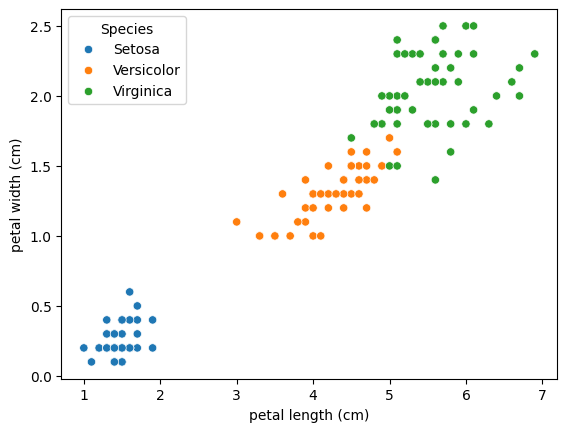

In [47]:
sns.scatterplot(data=df, x= "petal length (cm)", y= "petal width (cm)", hue= "Species")

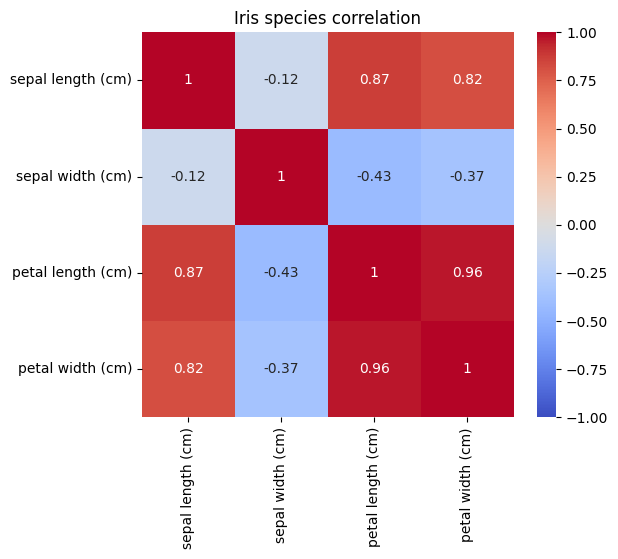

In [51]:
import matplotlib.pyplot as plt
import numpy as np

feature_columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
corr = df[feature_columns].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, vmin= -1, vmax= 1, center=0, cmap="coolwarm")
plt.title("Iris species correlation")
plt.show()

#### e, Create boxplot

<Axes: xlabel='species', ylabel='sepal width (cm)'>

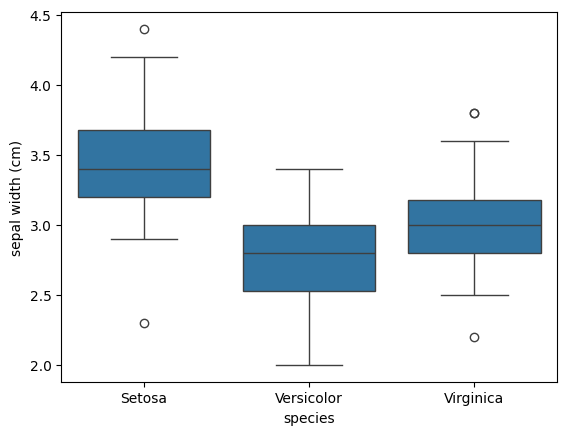

In [60]:
sns.boxplot(data=df, x="species", y="sepal width (cm)", gap=0) #(hue="Species")

<Axes: >

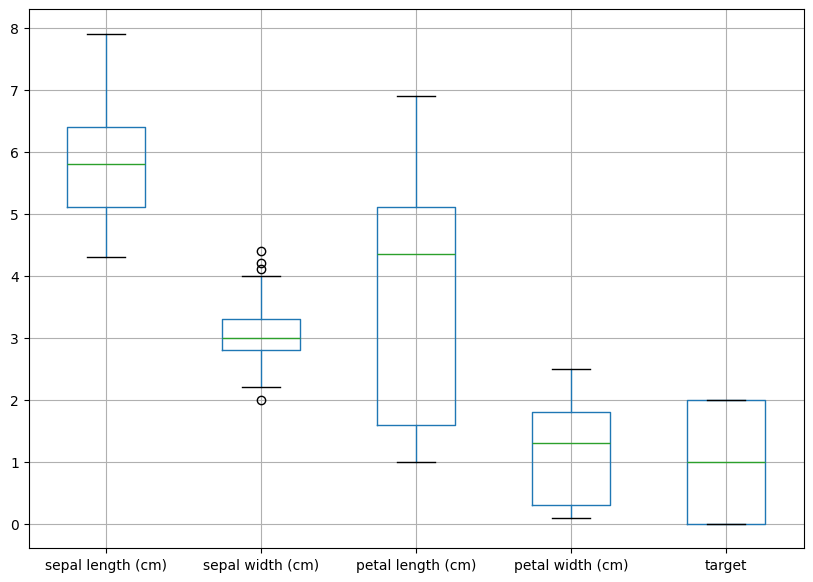

In [64]:
plt.figure(figsize=(10,7))
df.boxplot()

In [ ]:
# Remove outliers in data from boxplot using Tukey's rule 

feature_columns = df.select_dtypes(include=np.number).drop